# Notebook 4: Grid Tree Data to EnMAP Image Pixels

This is the fourth notebook in the sequence for the HRS Botany project.

In it we will grid the cleaned tree data by it's overlapping EnMAP image pixels. 


__Notebook Inputs:__
- Plot Dataset (_data/plots.csv_)
- Cleaned and merged Tree Dataset (_data/trees.csv_)
- Trimmed EnMAP tiffs and sidecar metadata JSONs 

__Notebook Outputs:__
- Cleaned and merged Tree Dataset (_data/trees.csv_)


In [ ]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
import rasterio
from shapely.geometry import box, Point
from rasterio.transform import rowcol
import matplotlib.pyplot as plt

class TreeEnmapGridder:
    def __init__(self, trees_gdf, plots_gdf, enmap_scene_root, output_table_root):
        self.trees = trees_gdf
        self.plots = plots_gdf
        self.enmap_scene_root = Path(enmap_scene_root)
        self.output_table_root = Path(output_table_root)

    def _assign_pixels(self, tiff_path, plot_id):
        with rasterio.open(tiff_path) as src:
            transform = src.transform
            tiff_crs = src.crs
            plot_geom = self.plots[self.plots["plot_id"] == plot_id]
            if plot_geom.empty:
                raise ValueError(f"Plot ID '{plot_id}' not found.")
            trees_subset = self.trees[self.trees["plot_id"] == plot_id]
            if trees_subset.empty:
                return pd.DataFrame(), src
            trees_in_plot = gpd.clip(trees_subset, plot_geom).to_crs(tiff_crs)
            coords = [(geom.x, geom.y) for geom in trees_in_plot.geometry]
            rows_cols = [rowcol(transform, x, y) for x, y in coords]
            trees_in_plot["row"], trees_in_plot["col"] = zip(*rows_cols)
            trees_in_plot["pixel_id"] = trees_in_plot.apply(lambda r: f"{r.row}_{r.col}", axis=1)
            return trees_in_plot, src

    def _generate_pixel_grid(self, src):
        transform = src.transform
        width, height = src.width, src.height
        records = []
        for row in range(height):
            for col in range(width):
                x_min, y_max = transform * (col, row)
                x_max = x_min + transform.a
                y_min = y_max + transform.e
                records.append({
                    "row": row,
                    "col": col,
                    "pixel_id": f"{row}_{col}",
                    "geometry": box(x_min, y_min, x_max, y_max),
                    "centroid": Point((x_min + x_max) / 2, (y_min + y_max) / 2)
                })
        return pd.DataFrame(records)

    def _make_table(self, trees_proj, src, species_col="gbif_taxon_key", binary=False):
        pixel_grid = self._generate_pixel_grid(src)
        if trees_proj.empty:
            return gpd.GeoDataFrame(pixel_grid, geometry="geometry", crs=src.crs)
        grouped = trees_proj.groupby(["pixel_id", trees_proj[species_col]]).size()
        table = grouped.unstack(fill_value=0).reset_index()
        if binary:
            table.iloc[:, 1:] = (table.iloc[:, 1:] > 0).astype(int)
        full = pixel_grid.merge(table, on="pixel_id", how="left").fillna(0)
        full.update(full.select_dtypes(include="number").astype(int))
        return gpd.GeoDataFrame(full, geometry="geometry", crs=src.crs)

    def process_all_scenes(self, mode="presence_absence", overwrite=False):
        assert mode in ["presence_absence", "counts"]
        for plot_dir in self.enmap_scene_root.iterdir():
            if not plot_dir.is_dir():
                continue
            plot_id = plot_dir.name
            for scene_dir in plot_dir.iterdir():
                if not scene_dir.is_dir():
                    continue
                tiffs = list(scene_dir.glob("*SPECTRAL_IMAGE_COG.tiff"))
                if not tiffs:
                    continue
                tiff_path = tiffs[0]
                out_dir = self.output_table_root / plot_id / scene_dir.name
                out_dir.mkdir(parents=True, exist_ok=True)
                out_file = out_dir / f"{mode}.geojson"
                if out_file.exists() and not overwrite:
                    continue
                try:
                    trees_proj, src = self._assign_pixels(tiff_path, plot_id)
                    result = self._make_table(
                        trees_proj, src,
                        species_col="gbif_taxon_key",
                        binary=(mode == "presence_absence")
                    )
                    result.to_file(out_file, driver="GeoJSON")
                except Exception as e:
                    print(f"Failed for {plot_id} / {scene_dir.name}: {e}")

    def plot_species_grid_multiscene(
        self,
        plot_id,
        species,
        mode="presence_absence",
        cmap="Greens",
        edgecolor="none",
        alpha_inside=1.0,
        alpha_outside=0.2,
        boundary_color="black",
        figsize=(6, 6),
        max_cols=3,
    ):
        plot_dir = self.output_table_root / plot_id
        if not plot_dir.exists():
            raise FileNotFoundError(f"No output directory for plot {plot_id}")
        geojson_paths = sorted(plot_dir.glob(f"**/{mode}.geojson"))
        if not geojson_paths:
            raise FileNotFoundError(f"No {mode}.geojson files found for plot {plot_id}")
        plot_geom = self.plots[self.plots["plot_id"] == plot_id]
        if plot_geom.empty:
            raise ValueError(f"Plot ID '{plot_id}' not found in plots")
        n = len(geojson_paths)
        ncols = min(n, max_cols)
        nrows = (n + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(figsize[0]*ncols, figsize[1]*nrows))
        axes = axes.flat if n > 1 else [axes]
        for ax, path in zip(axes, geojson_paths):
            gdf = gpd.read_file(path)
            if species not in gdf.columns:
                print(f"Skipping {path.name} — species '{species}' not found")
                ax.set_axis_off()
                continue
            plot_geom_proj = plot_geom.to_crs(gdf.crs)
            gdf["inside_plot"] = gdf.centroid.within(plot_geom_proj.iloc[0].geometry)
            inside = gdf[gdf["inside_plot"]]
            outside = gdf[~gdf["inside_plot"]]
            if not outside.empty:
                outside.plot(ax=ax, color="lightgrey", edgecolor=edgecolor, alpha=alpha_outside)
            inside.plot(
                ax=ax,
                column=species,
                cmap=cmap,
                legend=False,
                edgecolor=edgecolor,
                alpha=alpha_inside,
            )
            plot_geom_proj.boundary.plot(ax=ax, color=boundary_color, linewidth=2)
            ax.set_title(path.parent.name.replace("ENMAP01-____L2A-", ""), fontsize=8)
            ax.set_axis_off()
        for ax in axes[n:]:
            ax.set_axis_off()
        fig.suptitle(f"{species} — Plot {plot_id}", fontsize=14)
        fig.tight_layout()
        return fig

    def plot_species_grid_multiscene_fancy(
        self,
        plot_id,
        species,
        mode="presence_absence",
        rgb_image=None,
        extent=None,
        max_cols=3,
        buffer=50,
        figsize=(6, 6),
    ):
        plot_dir = self.output_table_root / plot_id
        if not plot_dir.exists():
            raise FileNotFoundError(f"No output directory for plot {plot_id}")
        
        geojson_paths = sorted(plot_dir.glob(f"**/{mode}.geojson"))
        if not geojson_paths:
            raise FileNotFoundError(f"No {mode}.geojson files found for plot {plot_id}")
        
        plot_geom = self.plots[self.plots["plot_id"] == plot_id]
        if plot_geom.empty:
            raise ValueError(f"Plot ID '{plot_id}' not found in plots")

        n = len(geojson_paths)
        ncols = min(n, max_cols)
        nrows = (n + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(figsize[0]*ncols, figsize[1]*nrows))
        axes = axes.flat if n > 1 else [axes]

        binary_cmap = cm.get_cmap("Greens", 2)
        norm = Normalize(vmin=0, vmax=1)

        for ax, path in zip(axes, geojson_paths):
            gdf = gpd.read_file(path)
            if species not in gdf.columns:
                print(f"Skipping {path.name} — species '{species}' not found")
                ax.set_axis_off()
                continue

            plot_geom_proj = plot_geom.to_crs(gdf.crs)
            gdf["inside_plot"] = gdf.centroid.within(plot_geom_proj.iloc[0].geometry)
            gdf["presence"] = (gdf[species] > 0).astype(int)

            # RGB background
            if rgb_image is not None and extent is not None:
                ax.imshow(rgb_image, extent=extent, origin="upper", alpha=1.0, zorder=1)

            # Grid presence
            gdf.plot(
                ax=ax,
                column="presence",
                cmap=binary_cmap,
                norm=norm,
                edgecolor="gray",
                linewidth=0.2,
                alpha=0.8,
                zorder=2
            )

            # Plot boundary
            plot_geom_proj.boundary.plot(
                ax=ax,
                color="red",
                linewidth=2,
                zorder=3
            )

            # Zoom
            xmin, ymin, xmax, ymax = plot_geom_proj.total_bounds
            ax.set_xlim(xmin - buffer, xmax + buffer)
            ax.set_ylim(ymin - buffer, ymax + buffer)

            # Labels
            ax.set_title(path.parent.name.replace("ENMAP01-____L2A-", ""), fontsize=10)
            ax.set_xlabel("Easting")
            ax.set_ylabel("Northing")

        # Turn off any unused axes
        for ax in axes[n:]:
            ax.set_axis_off()

        # Shared legend
        zero_patch = mpatches.Patch(color=binary_cmap(norm(0)), label="0 stems")
        one_patch = mpatches.Patch(color=binary_cmap(norm(1)), label=">0 stems")
        fig.legend(
            handles=[zero_patch, one_patch],
            title="Presence",
            loc="lower center",
            ncol=2,
            bbox_to_anchor=(0.5, -0.01)
        )

        fig.suptitle(f"{species} — Plot {plot_id}", fontsize=14)
        plt.tight_layout()
        plt.subplots_adjust(bottom=0.10)
        return fig

In [163]:
trees_gdf = gpd.read_file("data/trees.gpkg")
trees_gdf.gbif_taxon_key = trees_gdf.gbif_taxon_key.fillna(-1)
trees_gdf.gbif_taxon_key = trees_gdf.gbif_taxon_key.astype(int).astype(str)
plots_df = pd.read_csv("data/plots.csv", index_col=0)
plots_df['geometry'] = plots_df['geometry'].apply(wkt.loads)
plots_gdf = gpd.GeoDataFrame(plots_df, geometry='geometry', crs="EPSG:4326")

In [164]:
gbif_to_common_name_mapping_dict = (
    trees_gdf[['gbif_taxon_key', 'common_name']]
    .drop_duplicates()
    .set_index('gbif_taxon_key')['common_name']
    .to_dict()
)

gbif_to_scientific_name_mapping_dict = (
    trees_gdf[['gbif_taxon_key', 'scientific_name']]
    .drop_duplicates()
    .set_index('gbif_taxon_key')['scientific_name']
    .to_dict()
)

In [166]:

enmap_dir = "./data/enmap_downloads/enmap_downloads_20250708"
output_table_root = "./data/output_tables/"

gridder = TreeEnmapGridder(trees_gdf, plots_gdf, enmap_scene_root=enmap_dir, output_table_root=output_table_root)


In [168]:
gridder.process_all_scenes(
    mode="presence_absence",  # or "counts"
    overwrite=True,
    
)


In [ ]:
gridder.plot_species_grid_multiscene(
        self,
        plot_id,
        species,
        mode="presence_absence",
        cmap="Greens",
        edgecolor="none",
        alpha_inside=1.0,
        alpha_outside=0.2,
        boundary_color="black",
        figsize=(6, 6),
        max_cols=3,
    ):

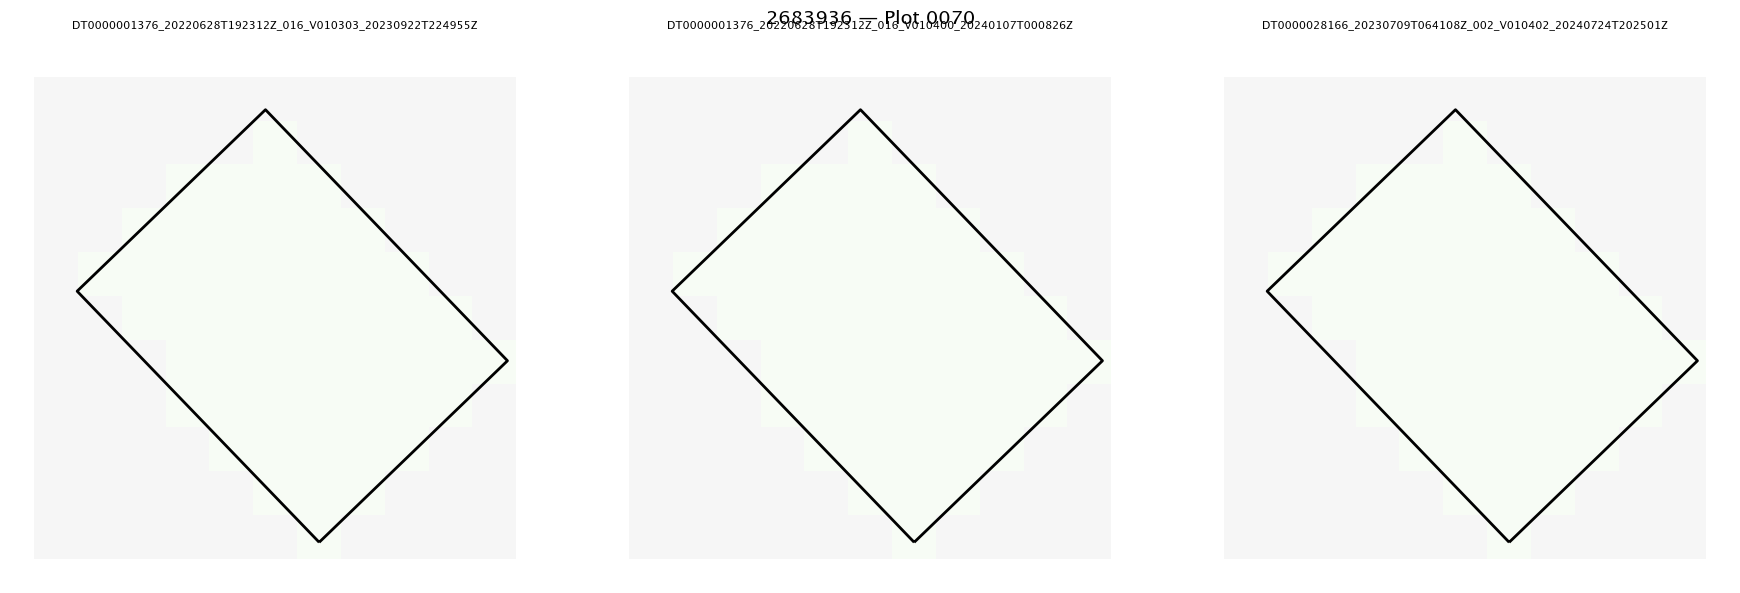

In [172]:
gridder.plot_species_grid_multiscene(
    plot_id="0070",
    species="2683936",
    mode="presence_absence"
)
plt.show()


In [135]:
import geopandas as gpd

# Path to one of the outputs
geojson_path = "./data/output_tables/0059/ENMAP01-____L2A-DT0000025893_20230704T194131Z_002_V010402_20240724T135222Z/presence_absence.geojson"

# Read it
gdf = gpd.read_file(geojson_path)

gdf = gdf.rename(columns=gbif_to_scientific_name_mapping_dict)

gdf


,row,col,pixel_id,centroid,Pseudotsuga menziesii (Mirb.) Franco,Tsuga mertensiana,Quercus xmorehus,Quercus garryana Douglas ex Hook.,Pinus lambertiana Douglas,Pinus ponderosa Lawson & C. Lawson,geometry
0,0,0,0_0,POINT (527220 4296930),0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((527235 4296915, 527235 4296945, 5272..."
1,0,1,0_1,POINT (527250 4296930),0.0,0.0,0.0,1.0,0.0,0.0,"POLYGON ((527265 4296915, 527265 4296945, 5272..."
2,0,2,0_2,POINT (527280 4296930),0.0,1.0,0.0,0.0,0.0,0.0,"POLYGON ((527295 4296915, 527295 4296945, 5272..."
3,0,3,0_3,POINT (527310 4296930),0.0,0.0,0.0,0.0,1.0,1.0,"POLYGON ((527325 4296915, 527325 4296945, 5272..."
4,0,4,0_4,POINT (527340 4296930),0.0,0.0,0.0,0.0,0.0,1.0,"POLYGON ((527355 4296915, 527355 4296945, 5273..."
5,1,0,1_0,POINT (527220 4296900),0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((527235 4296885, 527235 4296915, 5272..."
6,1,1,1_1,POINT (527250 4296900),0.0,1.0,1.0,0.0,0.0,1.0,"POLYGON ((527265 4296885, 527265 4296915, 5272..."
7,1,2,1_2,POINT (527280 4296900),1.0,1.0,0.0,0.0,1.0,1.0,"POLYGON ((527295 4296885, 527295 4296915, 5272..."
8,1,3,1_3,POINT (527310 4296900),0.0,0.0,0.0,0.0,1.0,1.0,"POLYGON ((527325 4296885, 527325 4296915, 5272..."
9,1,4,1_4,POINT (527340 4296900),0.0,0.0,0.0,0.0,0.0,1.0,"POLYGON ((527355 4296885, 527355 4296915, 5273..."


In [ ]:
df_renamed = gdf.rename(columns=gbif_to_common_name_mapping_dict)